# Florence Bounding Box Analysis of Boxes

In [ ]:
class Args:
    out=None
    eval=False
    format_only=False
    show=False

args=Args()

assert args.out or args.eval or args.format_only or args.show \
    or args.show_dir, \
    ('Please specify at least one operation (save/eval/format/show the '
        'results / save the results) with the argument "--out", "--eval"'
        ', "--format-only", "--show" or "--show-dir"')

if args.eval and args.format_only:
    raise ValueError('--eval and --format_only cannot be both specified')

if args.out is not None and not args.out.endswith(('.pkl', '.pickle')):
    raise ValueError('The output file must be a pkl file.')

cfg = Config.fromfile(args.config)
if args.cfg_options is not None:
    cfg.merge_from_dict(args.cfg_options)
# import modules from string list.
if cfg.get('custom_imports', None):
    from mmcv.utils import import_modules_from_strings
    import_modules_from_strings(**cfg['custom_imports'])
# set cudnn_benchmark
if cfg.get('cudnn_benchmark', False):
    torch.backends.cudnn.benchmark = True

cfg.model.pretrained = None
cfg.data.test.update(dict(samples_per_gpu=args.bs))

# in case the test dataset is concatenated
samples_per_gpu = 1
if isinstance(cfg.data.test, dict):
    cfg.data.test.test_mode = True
    samples_per_gpu = cfg.data.test.pop('samples_per_gpu', 1)
    if samples_per_gpu > 1:
        # Replace 'ImageToTensor' to 'DefaultFormatBundle'
        cfg.data.test.pipeline = replace_ImageToTensor(
            cfg.data.test.pipeline)
elif isinstance(cfg.data.test, list):
    for ds_cfg in cfg.data.test:
        ds_cfg.test_mode = True
    samples_per_gpu = max(
        [ds_cfg.pop('samples_per_gpu', 1) for ds_cfg in cfg.data.test])
    if samples_per_gpu > 1:
        for ds_cfg in cfg.data.test:
            ds_cfg.pipeline = replace_ImageToTensor(ds_cfg.pipeline)

# init distributed env first, since logger depends on the dist info.
if args.launcher == 'none':
    distributed = False
    cfg.data.workers_per_gpu = 1
else:
    distributed = True
    init_dist(args.launcher, **cfg.dist_params)

# set random seeds
if args.seed is not None:
    set_random_seed(args.seed, deterministic=args.deterministic)

# build the dataloader
dataset = build_dataset(cfg.data.test)
data_loader = build_dataloader(
    dataset,
    samples_per_gpu=samples_per_gpu,
    workers_per_gpu=cfg.data.workers_per_gpu,
    dist=distributed,
    shuffle=False)

In [1]:
# https://huggingface.co/microsoft/Florence-2-large/blob/main/sample_inference.ipynb
import torch
from torchvision import datasets
import torchvision.transforms as transforms
import os
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import florence_pytorch.florence.modeling_florence2 as flor2
from florence_pytorch.florence.configuration_florence2 import *
from florence_pytorch.florence.florence_attn import *
from florence_pytorch.florence.utils import unnormalize, normalize

import numpy as np

import matplotlib.pyplot as plt  
import matplotlib.patches as patches  
import math
import random

/home/tkg5kq/.conda/envs/bound/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/tkg5kq/.conda/envs/bound/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tkg5kq/.conda/envs/bound/lib/python3.12/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def run_task(flo_model, processor, image, task_prompt, device, text_prompt=''):
    task_prompt = f'<{task_prompt}>'
    if text_prompt != '':
        prompt = f'{task_prompt}{text_prompt}'
    else:
        prompt = task_prompt

    inputs = processor(text=prompt, images=image, return_tensors="pt")

    input_ids = inputs["input_ids"].to(device)
    pixel_values = inputs["pixel_values"].to(device)
    generated_ids = flo_model.generate(
        input_ids=input_ids,
        pixel_values=pixel_values,
        max_new_tokens=1024,
        early_stopping=False,
        do_sample=False,
        num_beams=3,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)

    # print(generated_text)

    parsed_answer = processor.post_process_generation(
        generated_text[0],
        task=task_prompt,
        image_size=(image.size[0], image.size[1])
    )
    return parsed_answer, task_prompt

In [3]:
def plot_bbox(image, bboxes, labels):
   # Create a figure and axes  
    fig, ax = plt.subplots()  
      
    # Display the image  
    ax.imshow(image)  
      
    # Plot each bounding box  
    for bbox, label in zip(bboxes, labels):  
        # Unpack the bounding box coordinates  
        x1, y1, x2, y2 = bbox  
        # Create a Rectangle patch  
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')  
        # Add the rectangle to the Axes  
        ax.add_patch(rect)  
        # Annotate the label  
        plt.text(x1, y1, label, color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))  
      
    # Remove the axis ticks and labels  
    ax.axis('off')  
      
    # Show the plot  
    plt.show()  

In [4]:

colormap = ['blue','orange','green','purple','brown','pink','gray','olive','cyan','red',
            'lime','indigo','violet','aqua','magenta','coral','gold','tan','skyblue', 'black']
def draw_polygons(image, polygons, labels, fill_mask=False, use_color=True):  
    """  
    Draws segmentation masks with polygons on an image.  
  
    Parameters:  
    - image_path: Path to the image file.  
    - prediction: Dictionary containing 'polygons' and 'labels' keys.  
                  'polygons' is a list of lists, each containing vertices of a polygon.  
                  'labels' is a list of labels corresponding to each polygon.  
    - fill_mask: Boolean indicating whether to fill the polygons with color.  
    """  
    # Load the image  
   
    draw = ImageDraw.Draw(image)  
      
   
    # Set up scale factor if needed (use 1 if not scaling)  
    scale = 1  
      
    # Iterate over polygons and labels 
    for polygon, label in zip(polygons, labels):  
        # print(polygon, label) 
        if use_color:
            color = random.choice(colormap)  
            fill_color = random.choice(colormap) if fill_mask else None  
        else:
            color = 'black'
            fill_color = 'black'

        for _polygon in polygon: 
            _polygon = np.array(_polygon).reshape(-1, 2)  
            if len(_polygon) < 3:  
                print('Invalid polygon:', _polygon)  
                continue  
              
            _polygon = (_polygon * scale).reshape(-1).tolist()  
              
            # Draw the polygon  
            if fill_mask:  
                draw.polygon(_polygon, outline=color, fill=fill_color)  
            else:  
                draw.polygon(_polygon, outline=color)  
              
            # Draw the label text  
            draw.text((_polygon[0] + 8, _polygon[1] + 2), label, fill=color)  

In [5]:

def create_mask(image, polygons, labels, fill_mask=False, use_color=True):  
    """  
    Draws segmentation masks with polygons on an image.  
  
    Parameters:  
    - image_path: Path to the image file.  
    - prediction: Dictionary containing 'polygons' and 'labels' keys.  
                  'polygons' is a list of lists, each containing vertices of a polygon.  
                  'labels' is a list of labels corresponding to each polygon.  
    - fill_mask: Boolean indicating whether to fill the polygons with color.  
    """  
    # Load the image  
   
      
   
    # Set up scale factor if needed (use 1 if not scaling)  
    scale = 1  
    masks = []
    transform = transforms.ToTensor()
    # Iterate over polygons and labels 
    for polygon, label in zip(polygons, labels):  
        mask = Image.new("RGB", (image.width, image.height), (0, 0, 0))
        draw = ImageDraw.Draw(mask)
        color = 'white'
        fill_color = 'white'

        for _polygon in polygon: 
            _polygon = np.array(_polygon).reshape(-1, 2)  
            if len(_polygon) < 3:  
                print('Invalid polygon:', _polygon)  
                continue  
              
            _polygon = (_polygon * scale).reshape(-1).tolist()
              
            # Draw the polygon  
            if fill_mask:  
                draw.polygon(_polygon, outline=color, fill=fill_color)  
            else:  
                draw.polygon(_polygon, outline=color)  
              
            # Draw the label text  
            draw.text((_polygon[0] + 8, _polygon[1] + 2), label, fill=color)  
            masks.append(transform(mask))
    return torch.stack(masks)

In [6]:
import re
def convert_str_to_bb(s):
    result = [int(x) for x in re.findall(r"<loc_(\d+)>", s)]
    return result

def convert_bb_to_str(bb):
    out_str = ''
    for b in bb:
        out_str += f'<loc_{math.ceil(b)}>'
    return out_str

In [7]:
device = "cuda:0"

flo_model, processor = flor2.load("LARGE_FT", device, revision=None)

/home/tkg5kq/.conda/envs/bound/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:693: UserWarning: Model with `tie_word_embeddings=True` and the tied_target_modules=['language_model.lm_head'] are part of the adapter. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. See for example https://github.com/huggingface/peft/issues/2018.
  warnings.warn(


In [8]:
def unnormalize(bb, w, h):
    """unnormalize
    Changes the florence style bounding box into the picture's scale
    """
    new_bb = []
    for i, b in enumerate(bb):
        if i % 2 != 0:
            new_bb.append((b/1000)*h)
        else:
            new_bb.append((b/1000)*w)
    return new_bb

def normalize(bb, w, h):
    """normalize
    Changes the bounding box given into florence style bounding boxes
    """
    new_bb = []
    for i, b in enumerate(bb):
        if i % 2 != 0:
            new_bb.append(math.ceil((b/h)*1000))
        else:
            new_bb.append(math.ceil((b/w)*1000))
    return new_bb

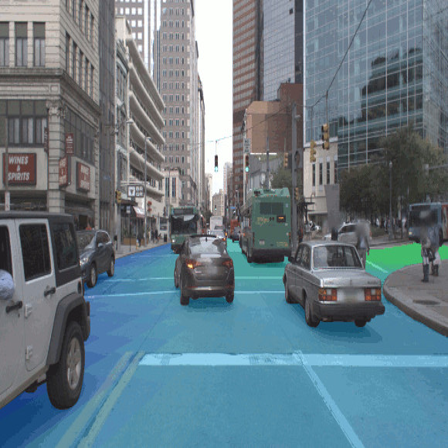

In [9]:
file_path = f'./map_ground_height.jpg'
height = 448
width = 448
image = Image.open(file_path)
image = image.resize((height, width)) #.crop((120, 0, width, height)).resize((height, width))
# import requests
# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/car.jpg?download=true"
# image = Image.open(requests.get(url, stream=True).raw)
image

In [10]:
task = 'REFERRING_EXPRESSION_SEGMENTATION'
norm_str = 'cars'
results = run_task(flo_model, processor, image, task, device, norm_str) 

print(results)

({'<REFERRING_EXPRESSION_SEGMENTATION>': {'polygons': [[[0.2240000069141388, 210.7840118408203, 47.263999938964844, 210.7840118408203, 48.15999984741211, 212.1280059814453, 57.56800079345703, 213.4720001220703, 69.21600341796875, 213.4720001220703, 71.90399932861328, 214.81600952148438, 73.24800109863281, 216.16000366210938, 74.14400482177734, 218.84800720214844, 74.14400482177734, 224.22401428222656, 75.04000091552734, 225.12001037597656, 75.93600463867188, 229.15200805664062, 75.93600463867188, 233.1840057373047, 76.83200073242188, 238.5600128173828, 77.7280044555664, 239.9040069580078, 78.6240005493164, 243.48800659179688, 78.6240005493164, 248.864013671875, 79.52000427246094, 250.2080078125, 79.96800231933594, 254.24000549316406, 79.96800231933594, 260.96002197265625, 80.86400604248047, 266.33599853515625, 81.76000213623047, 267.6800231933594, 82.656005859375, 271.2640075683594, 82.656005859375, 276.6400146484375, 83.552001953125, 277.9840087890625, 84.0, 282.0160217285156, 84.8960

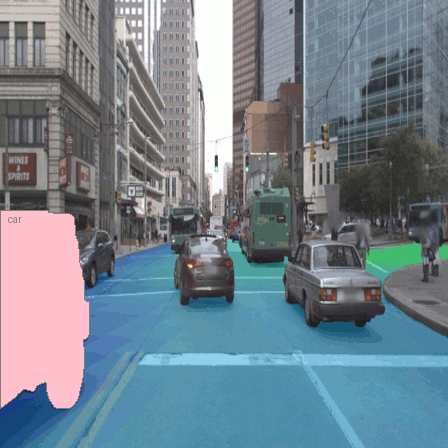

In [11]:
output_image = copy.deepcopy(image)
box = results[0][results[1]]['polygons'][0][0]
draw_polygons(output_image, [[box]], ['car'], fill_mask=True) 
output_image 

In [12]:
task = 'OD'
norm_str = ''
results = run_task(flo_model, processor, image, task, device, norm_str) 

print(results)

({'<OD>': {'bboxes': [[0.2240000069141388, 210.3360137939453, 92.06400299072266, 410.1440124511719], [282.0160217285156, 239.9040069580078, 385.5039978027344, 327.7120056152344], [172.70401000976562, 233.6320037841797, 235.42401123046875, 305.760009765625], [75.48799896240234, 229.15200805664062, 116.2560043334961, 287.8399963378906], [335.7760009765625, 221.5360107421875, 372.51202392578125, 267.6800231933594], [207.64801025390625, 229.60000610351562, 226.01600646972656, 240.8000030517578], [229.60000610351562, 226.91200256347656, 240.8000030517578, 242.14401245117188], [407.4560241699219, 208.99200439453125, 444.1920166015625, 282.4640197753906], [320.99200439453125, 123.42400360107422, 330.4000244140625, 149.8560028076172], [308.89599609375, 140.447998046875, 316.96002197265625, 162.84800720214844], [243.93600463867188, 154.33599853515625, 250.2080078125, 172.70401000976562], [282.9120178222656, 152.09600830078125, 289.63201904296875, 168.2239990234375], [213.92001342773438, 154.784

In [13]:
task_output, task_label = results

print(task_output, task_label)
bbs = task_output[task_label]['bboxes']
bb_labels = task_output[task_label]['labels']

bb_list = []
norm_bb_list = []
for bb, label in zip(bbs, bb_labels):
    if label == 'car':
        bb_list.append(bb)

bb_list, len(bb_list)

{'<OD>': {'bboxes': [[0.2240000069141388, 210.3360137939453, 92.06400299072266, 410.1440124511719], [282.0160217285156, 239.9040069580078, 385.5039978027344, 327.7120056152344], [172.70401000976562, 233.6320037841797, 235.42401123046875, 305.760009765625], [75.48799896240234, 229.15200805664062, 116.2560043334961, 287.8399963378906], [335.7760009765625, 221.5360107421875, 372.51202392578125, 267.6800231933594], [207.64801025390625, 229.60000610351562, 226.01600646972656, 240.8000030517578], [229.60000610351562, 226.91200256347656, 240.8000030517578, 242.14401245117188], [407.4560241699219, 208.99200439453125, 444.1920166015625, 282.4640197753906], [320.99200439453125, 123.42400360107422, 330.4000244140625, 149.8560028076172], [308.89599609375, 140.447998046875, 316.96002197265625, 162.84800720214844], [243.93600463867188, 154.33599853515625, 250.2080078125, 172.70401000976562], [282.9120178222656, 152.09600830078125, 289.63201904296875, 168.2239990234375], [213.92001342773438, 154.7840

([[0.2240000069141388,
   210.3360137939453,
   92.06400299072266,
   410.1440124511719],
  [282.0160217285156, 239.9040069580078, 385.5039978027344, 327.7120056152344],
  [172.70401000976562,
   233.6320037841797,
   235.42401123046875,
   305.760009765625],
  [75.48799896240234,
   229.15200805664062,
   116.2560043334961,
   287.8399963378906],
  [335.7760009765625,
   221.5360107421875,
   372.51202392578125,
   267.6800231933594],
  [207.64801025390625,
   229.60000610351562,
   226.01600646972656,
   240.8000030517578],
  [229.60000610351562,
   226.91200256347656,
   240.8000030517578,
   242.14401245117188]],
 7)

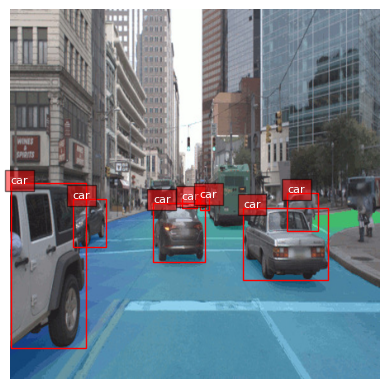

In [14]:
bbox_image = copy.deepcopy(image)
plot_bbox(bbox_image, bb_list, ['car' for _ in range(len(bb_list))])

In [15]:
bb_strs = []
for bb in bb_list:
    bb_strs.append(convert_bb_to_str(normalize(bb, image.width, image.height)))
bb_strs

['<loc_1><loc_470><loc_206><loc_916>',
 '<loc_630><loc_536><loc_861><loc_732>',
 '<loc_386><loc_522><loc_526><loc_683>',
 '<loc_169><loc_512><loc_260><loc_643>',
 '<loc_750><loc_495><loc_832><loc_598>',
 '<loc_464><loc_513><loc_505><loc_538>',
 '<loc_513><loc_507><loc_538><loc_541>']

In [16]:
task = 'REGION_TO_SEGMENTATION'

results_list = []
copy_image = copy.deepcopy(image)
for str in bb_strs:
    output = run_task(flo_model, processor, copy_image, task, device, str) 
    results_list.append(output)
results_list, len(results_list)

([({'<REGION_TO_SEGMENTATION>': {'polygons': [[[0.2240000069141388,
        210.7840118408203,
        47.263999938964844,
        210.7840118408203,
        48.15999984741211,
        212.1280059814453,
        54.880001068115234,
        213.4720001220703,
        66.08000183105469,
        213.4720001220703,
        71.00800323486328,
        214.81600952148438,
        72.80000305175781,
        216.16000366210938,
        73.69599914550781,
        218.84800720214844,
        74.59200286865234,
        222.8800048828125,
        75.48799896240234,
        227.80801391601562,
        76.38400268554688,
        231.8400115966797,
        77.27999877929688,
        237.21600341796875,
        78.1760025024414,
        242.59201049804688,
        79.07200622558594,
        247.96800231933594,
        79.96800231933594,
        254.24000549316406,
        79.96800231933594,
        263.64801025390625,
        80.86400604248047,
        264.99200439453125,
        81.76000213623047,
   

In [18]:
# polygons = [[convert_str_to_bb(output[0][output[1]])]]
polygons = []
labels = []
for result in results_list:
    result = result[0][result[1]]
    # print(result['polygons'][0])
    polygons.append([result['polygons'][0][0]])
    labels.append('car')

# polygons = [[polygon] for polygon in results_list[0][list(results_list[0].keys())[0]]['polygons']]
# labels = ['car' for _ in results_list]
print(len(polygons[0][0]))

116


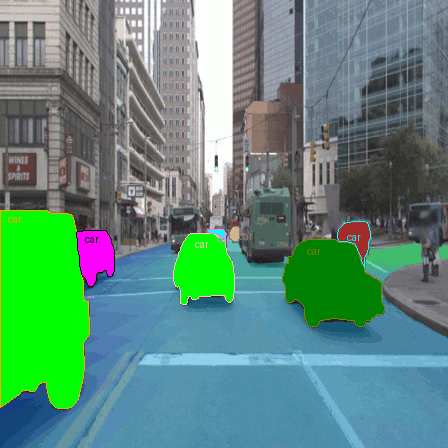

In [19]:
polygon_image = copy.deepcopy(image)
draw_polygons(polygon_image, polygons, labels, fill_mask=True)
polygon_image

In [20]:
len(polygons), len(bb_list)

(7, 7)

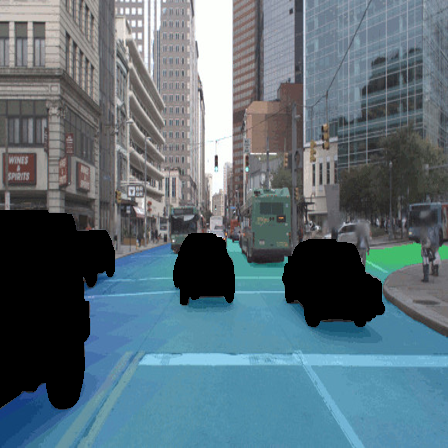

In [21]:
size_ratio_threshold = 1e-2
image_area = image.height*image.width
# print(unnormalize(bb_list[0], width, height))
filtered_polygons = []
for bb, polygon in zip(bb_list, polygons):
    # bb = unnormalize(bb, width, height)
    width = bb[2] - bb[0]
    height = bb[3] - bb[1]
    area = width*height
    
    ratio = area/image_area
    if ratio > size_ratio_threshold:
        filtered_polygons.append(polygon)

f_polygon_image = copy.deepcopy(image)
draw_polygons(f_polygon_image, filtered_polygons, labels, fill_mask=True, use_color=False)
f_polygon_image

torch.Size([4, 3, 448, 448])


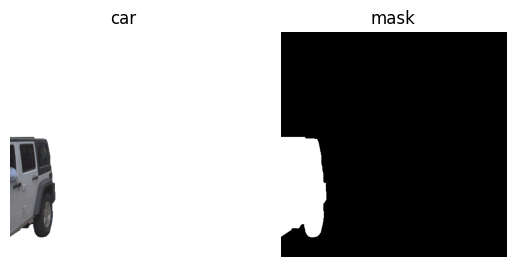

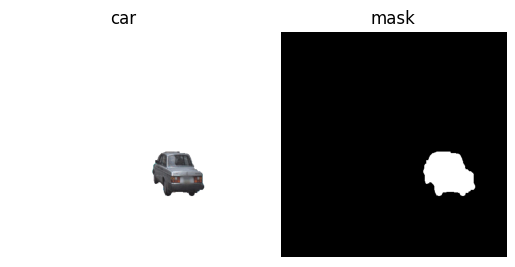

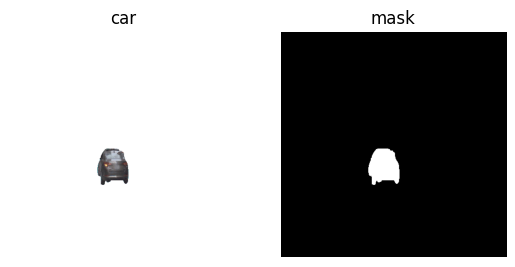

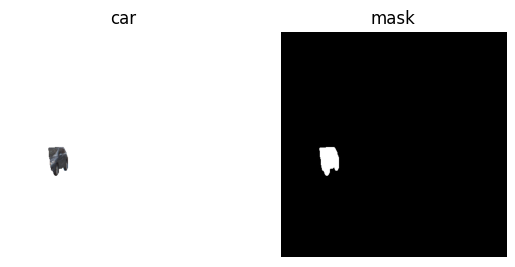

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [22]:
masks = create_mask(f_polygon_image, filtered_polygons, labels, fill_mask=True, use_color=False)
print(masks.shape)

# idx = random.randint(0, mask.shape[0])
for idx in range(0, masks.shape[0]):
    mask = masks[idx]

    plt.figure()
    plt.subplot(1, 2, 1)
    tmp = mask.permute(1, 2, 0).cpu().detach().numpy() * transforms.ToTensor()(image).permute(1, 2, 0).numpy()
    tmp[tmp == 0] = 1
    plt.imshow(tmp)
    plt.title('car')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    tmp = mask.permute(1, 2, 0).cpu().detach().numpy() 
    # zero_mask = (tmp == 0)
    # one_mask = (tmp == 1)
    # tmp[zero_mask] = 1
    # tmp[one_mask] = 0
    plt.imshow(tmp)
    plt.title('mask')
    plt.axis('off')
    plt.show()

mask

In [23]:
masks = create_mask(f_polygon_image, filtered_polygons, labels, fill_mask=True, use_color=False)
print(masks.shape)

idx = random.randint(0, mask.shape[0])
mask = masks[idx]
print(idx)

torch.Size([4, 3, 448, 448])
2


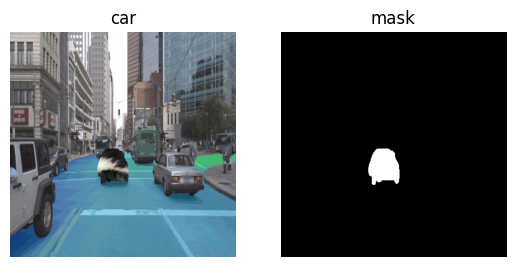

In [24]:
lily_img = Image.open('./Lily.jpg').resize((image.width, image.height))
plt.figure()
plt.subplot(1, 2, 1)
contour = torch.where((mask == 1), torch.zeros(1), torch.ones(1))
tmp = torch.where((contour == 1.), transforms.ToTensor()(image), transforms.ToTensor()(lily_img))
plt.imshow(tmp.permute(1,2, 0))
plt.title('car')
plt.axis('off')
plt.subplot(1, 2, 2)
tmp = mask.permute(1, 2, 0).cpu().detach().numpy() 
plt.imshow(tmp)
plt.title('mask')
plt.axis('off')
plt.show()